# Demo sintético — TrustGraph

Recorrido reproducible del proyecto: generación de datos, detección automática del esquema, construcción de Trust Cliente/Comercio, relaciones y grafo.

In [1]:
from pathlib import Path
import sys
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd()
if not (ROOT / "src").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "src"))

from trustgraph import TrustGraphPipeline, generate_synthetic_transactions

## 1. Generar datos sintéticos

In [2]:
df, metadata = generate_synthetic_transactions(
    n_clients=300, n_merchants=50, months=18, seed=42
)
print(df.shape)
df.head()

(37501, 11)


,cedula_cliente,id_tarjeta,codigo_unico_comercio,nit_comercio,fecha_transaccion,monto_transaccion,estado_transaccion,mcc,fecha_afiliacion,synthetic_deteriorating_client,synthetic_deteriorating_merchant
0,CL00197,CARD00197_0,MC0026,900100026,2025-01-01 07:05:00,30355.91,APROBADA,5912,2020-04-05,0,0
1,CL00201,CARD00201_0,MC0044,900100044,2025-01-01 07:41:00,61110.24,APROBADA,5411,2024-02-24,0,0
2,CL00159,CARD00159_1,MC0026,900100026,2025-01-01 07:42:00,43849.84,APROBADA,5912,2020-04-05,0,0
3,CL00110,CARD00110_0,MC0015,900100015,2025-01-01 07:58:00,42335.21,APROBADA,5732,2020-03-25,0,0
4,CL00042,CARD00042_0,MC0012,900100012,2025-01-01 08:09:00,51459.97,APROBADA,5732,2020-07-05,0,0


## 2. Detección automática de columnas y ejecución del pipeline

In [3]:
pipeline = TrustGraphPipeline.from_yaml(ROOT / "config" / "default.yaml")
result = pipeline.run(df)
result.schema.mapping

{'client_id': 'cedula_cliente',
 'card_id': 'id_tarjeta',
 'merchant_id': 'codigo_unico_comercio',
 'merchant_nit': 'nit_comercio',
 'transaction_date': 'fecha_transaccion',
 'amount': 'monto_transaccion',
 'status': 'estado_transaccion',
 'merchant_category': 'mcc',
 'merchant_affiliation_date': 'fecha_afiliacion'}

## 3. Trust Cliente mensual

In [4]:
cols = [
    "client_id", "month", "tx_count", "unique_merchants",
    "avg_relationship_strength", "trust_score", "trust_change_3m"
]
result.client_month[cols].tail(10)

,client_id,month,tx_count,unique_merchants,avg_relationship_strength,trust_score,trust_change_3m
5390,CL00299,2025-09-01,2,2,50.000000,77.767633,-8.536740
5391,CL00299,2025-10-01,7,3,41.944444,84.172892,-1.893118
5392,CL00299,2025-11-01,3,3,33.055556,72.321520,-13.531811
5393,CL00299,2025-12-01,5,3,45.000000,84.164541,6.396908
5394,CL00299,2026-01-01,6,4,33.333333,80.324023,-3.848869
5395,CL00299,2026-02-01,13,8,24.687500,75.331830,3.010310
5396,CL00299,2026-03-01,9,5,32.166667,78.236441,-5.928100
5397,CL00299,2026-04-01,11,4,44.166667,85.641775,5.317752
5398,CL00299,2026-05-01,4,3,55.277778,87.909763,12.577933
5399,CL00299,2026-06-01,8,6,37.500000,80.793996,2.557555


## 4. Trust Comercio mensual

In [5]:
cols = [
    "merchant_id", "month", "tx_count", "unique_clients",
    "repeat_customer_rate", "client_hhi", "trust_score", "trust_change_3m"
]
result.merchant_month[cols].tail(10)

,merchant_id,month,tx_count,unique_clients,repeat_customer_rate,client_hhi,trust_score,trust_change_3m
890,MC0049,2025-09-01,34,23,0.826087,0.062284,85.351667,0.067675
891,MC0049,2025-10-01,45,24,0.916667,0.052840,86.817443,1.396294
892,MC0049,2025-11-01,41,25,0.840000,0.057704,85.805653,1.206794
893,MC0049,2025-12-01,41,27,0.814815,0.044616,86.252487,0.900820
894,MC0049,2026-01-01,34,21,0.809524,0.064014,84.632187,-2.185255
895,MC0049,2026-02-01,46,24,0.833333,0.056711,85.762654,-0.042999
896,MC0049,2026-03-01,52,23,0.869565,0.057692,86.617628,0.365140
897,MC0049,2026-04-01,48,28,0.857143,0.047743,86.295875,1.663687
898,MC0049,2026-05-01,36,19,0.842105,0.069444,85.176585,-0.586069
899,MC0049,2026-06-01,44,24,0.875000,0.050620,85.851555,-0.766072


## 5. Fortaleza Cliente–Comercio

In [6]:
result.relationship_month[[
    "client_id", "merchant_id", "month", "tx_count",
    "relation_age_months", "relation_streak_months",
    "client_tx_share", "relationship_strength"
]].sort_values("relationship_strength", ascending=False).head(15)

,client_id,merchant_id,month,tx_count,relation_age_months,relation_streak_months,client_tx_share,relationship_strength
10288,CL00145,MC0007,2025-07-01,3,7,6,1.0,100.0
12610,CL00178,MC0009,2025-08-01,1,8,6,1.0,100.0
17548,CL00248,MC0001,2025-09-01,3,9,6,1.0,100.0
15114,CL00213,MC0016,2026-02-01,1,14,6,1.0,100.0
2777,CL00039,MC0026,2025-06-01,4,6,6,1.0,100.0
11555,CL00163,MC0049,2026-02-01,1,14,6,1.0,100.0
19315,CL00273,MC0014,2025-10-01,1,10,6,1.0,100.0
16405,CL00231,MC0015,2025-07-01,3,7,6,1.0,100.0
20760,CL00294,MC0035,2026-05-01,2,17,6,1.0,100.0
4836,CL00068,MC0011,2026-05-01,3,17,6,1.0,100.0


## 6. Validar que relaciones persistentes son más fuertes

In [7]:
rel = result.relationship_month
pd.Series({
    "relaciones_nuevas_1m": rel.loc[rel.relation_age_months == 1, "relationship_strength"].mean(),
    "relaciones_6m_o_mas": rel.loc[rel.relation_age_months >= 6, "relationship_strength"].mean(),
})

relaciones_nuevas_1m    17.561407
relaciones_6m_o_mas     51.623713
dtype: float64

## 7. Validar deterioro sintético

In [8]:
cm = result.client_month.copy()
cm["grupo"] = cm["client_id"].isin(metadata.deteriorating_clients).map({True:"Deterioro sintético", False:"Estable"})
series = cm.groupby(["month", "grupo"])["trust_score"].mean().unstack()
series.tail(8)

grupo,Deterioro sintético,Estable
month,,
2025-11-01,84.118705,83.710454
2025-12-01,82.845764,84.003806
2026-01-01,84.762621,83.539980
2026-02-01,82.825991,83.655570
2026-03-01,83.591759,83.588752
2026-04-01,79.856500,83.355024
2026-05-01,80.157280,83.497129
2026-06-01,78.362932,84.183927


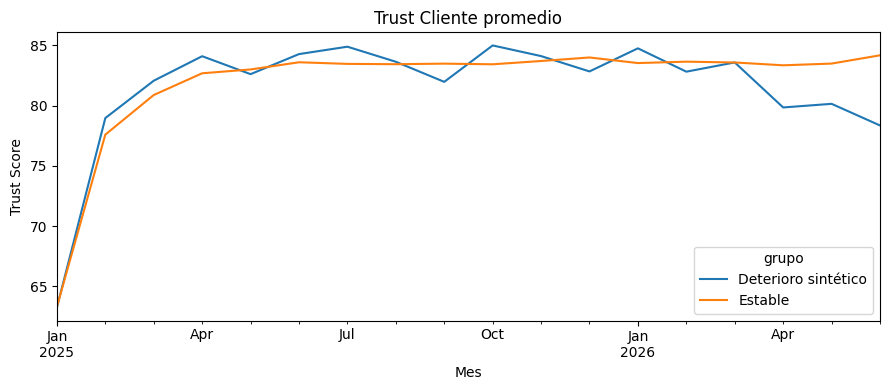

In [9]:
ax = series.plot(figsize=(9,4), title="Trust Cliente promedio")
ax.set_ylabel("Trust Score")
ax.set_xlabel("Mes")
plt.tight_layout()
plt.show()

## 8. Grafo y comunidades

In [10]:
print("Nodos:", result.graph.number_of_nodes())
print("Aristas:", result.graph.number_of_edges())
print("Comunidades cliente:", result.client_communities.community.nunique())
print("Comunidades comercio:", result.merchant_communities.community.nunique())
result.graph_metrics.sort_values("pagerank", ascending=False).head(10)

Nodos: 350
Aristas: 907
Comunidades cliente: 5
Comunidades comercio: 5


,node,entity_id,entity_type,trust_score,degree,weighted_degree,pagerank
45,M::MC0029,MC0029,merchant,87.391402,25,1436.505372,0.013043
36,M::MC0024,MC0024,merchant,88.136160,27,1406.052940,0.012767
37,M::MC0028,MC0028,merchant,86.450382,25,1446.876590,0.012736
13,M::MC0007,MC0007,merchant,85.740747,25,1358.900020,0.012619
25,M::MC0037,MC0037,merchant,84.450823,23,1329.451765,0.012227
74,M::MC0025,MC0025,merchant,87.461474,23,1336.227666,0.012086
49,M::MC0009,MC0009,merchant,87.173340,22,1196.181775,0.011775
40,M::MC0023,MC0023,merchant,88.619972,22,1311.763189,0.011730
76,M::MC0030,MC0030,merchant,88.270458,22,1242.954898,0.011480
65,M::MC0003,MC0003,merchant,85.407881,23,1200.422359,0.011228


## Lectura del resultado

El score no intenta etiquetar fraude. Evalúa confianza comportamental observable. La validación sintética comprueba que: (1) relaciones persistentes reciben mayor fortaleza; y (2) entidades cuyo comportamiento se deteriora artificialmente muestran una caída mayor del Trust Score.